# Customer Churn Prediction and Retention Analysis

## Machine Learning Project Life Cycle
- Understanding the Problem Statement
- Data Collection
- Data checks to perform
- Data pre-processing
- Exploratory Data Analysis
- Model Training
- Choose best model


## Problem Statement
This project analyzes the customer purchase history to group customers based on their buying behavior and identify who is likely to stop buying. Build a model to predict at-risk customers and estimate how much value each customer brings to the business, helping the company focus retention efforts where they matter most.

## Data Collection
- Dataset source - https://www.kaggle.com/datasets/vijayuv/onlineretail/data
- This dataset contains all purchases made for an online retail company based in the UK during an eight month period.
- The dataset consists of 8 columns and 541909 rows

## Import Data and required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Import the CSV data as Pandas Dataframe

In [2]:
df = pd.read_csv('Dataset/OnlineRetail.csv', encoding = "ISO-8859-1")

#### Show top 5 records

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Show bottom 5 records

In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


#### Shape of the dataset

In [5]:
df.shape

(541909, 8)

#### Dataset Information
- InvoiceNo: Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
- StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
- Description: Product (item) name. Nominal.
- Quantity: The quantities of each product (item) per transaction. Numeric.
- InvoiceDate: Invice Date and time. Numeric, the day and time when each transaction was generated.
- UnitPrice: Unit price. Numeric, Product price per unit in sterling.
- CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
- Country: Country name. Nominal, the name of the country where each customer resides.


## Data Cleaning:
### Data Checks to Perform
- Check Missing values
- Check Duplicate records
- Check data type
- Check the number of unique values in each
- Check statistics of the data set
- Check various categories present in each categorical column

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.duplicated().value_counts()

False    536641
True       5268
Name: count, dtype: int64

#### There are some duplicate records in the dataset and we are going to drop them

### First let's create a copy of this dataset

In [8]:
data = df.copy()

In [9]:
data.shape

(541909, 8)

In [10]:
data = data.drop_duplicates()
data.shape

(536641, 8)

In [11]:
data.duplicated().sum()

0

The duplicate records are dropped

In [12]:
data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

#### There are missing values in CustomerID, Description columns.
We can ignore the Description since it is an redundant feature and drop the rows with null values of CustomerID

In [13]:
data.dropna(subset=['CustomerID'], inplace=True)

In [14]:
data.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [15]:
data.shape

(401604, 8)

### We are now focusing on the datatypes and the data inside the features

In [16]:
cancelled_transactions = []
for i in data['InvoiceNo']:
    if str(i)[0]=='C':
        cancelled_transactions.append(i)

print(len(cancelled_transactions))

8872


So, there are 8872 cancelled transactions present in this dataset and removing these since we are not going to use them

In [17]:
data[data.InvoiceNo.isin(cancelled_transactions)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [18]:
data = data[data.InvoiceNo.isin(cancelled_transactions)==False]

In [19]:
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


The cancelled transactions are removed

#### We are changing this datatype into String

In [20]:
data['InvoiceNo'] = data['InvoiceNo'].astype(str)

#### We need to change the InvoiceDate type to datetime

In [21]:
data['InvoiceDate'].dtype

dtype('O')

In [22]:
data['InvoiceDate']

0          12/1/2010 8:26
1          12/1/2010 8:26
2          12/1/2010 8:26
3          12/1/2010 8:26
4          12/1/2010 8:26
               ...       
541904    12/9/2011 12:50
541905    12/9/2011 12:50
541906    12/9/2011 12:50
541907    12/9/2011 12:50
541908    12/9/2011 12:50
Name: InvoiceDate, Length: 392732, dtype: object

In [23]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [24]:
data['InvoiceDate'].dtype

dtype('<M8[ns]')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


#### We are making sure that the CustomerID data type is integer

In [26]:
data['CustomerID'] = data['CustomerID'].astype(int)

In [27]:
(data['Quantity']<0).any()

False

The Quantity has no negative values present in it

In [28]:
data[data['UnitPrice']==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410,United Kingdom


There are 40 records where unitprice is 0. So, we are dropping these rows since Zero unit prices don't represent real customer buying decisions. They impact monetary, Segmentation & churn Model

In [29]:
data = data[data['UnitPrice']!=0]

In [31]:
data.shape

(392692, 8)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(4)
memory usage: 25.5+ MB


#### Data Cleaning part is completed now

In [34]:
print(data['InvoiceDate'].min(), '→', data['InvoiceDate'].max())

2010-12-01 08:26:00 → 2011-12-09 12:50:00


---
## Time-Based Window Split

**Why time-based split?**  
Since we don't have churn label present in this dataset, we are following the RFM method & predicting it.   
We are splitting the dataset into training data, validation/prediction data.    
This allows recency to be used as a feature without data leakage.  
Features and churn labels are derived from completely separate time periods.

```
|———————— Training Window —————————|—— Prediction Window ——|
   Dec 2010 - Aug 2011                Sep 2011 - Dec 2011
   Calculate RFM features here        Define churn label here
```

In [35]:
# Define window boundaries
train_end   = pd.Timestamp('2011-09-01')  # split point
predict_end = data['InvoiceDate'].max()      # 9 Dec 2011

# Split transactions into two windows
train_df   = data[data['InvoiceDate'] <  train_end]
predict_df = data[
    (data['InvoiceDate'] >= train_end) &
    (data['InvoiceDate'] <= predict_end)
]

print('Training window  :', train_df['InvoiceDate'].min(), '→', train_df['InvoiceDate'].max())
print('Prediction window:', predict_df['InvoiceDate'].min(), '→', predict_df['InvoiceDate'].max())
print('Train transactions  :', len(train_df))
print('Predict transactions:', len(predict_df))
print('Train customers     :', train_df['CustomerID'].nunique())
print('Predict customers   :', predict_df['CustomerID'].nunique())

Training window  : 2010-12-01 08:26:00 → 2011-08-31 17:16:00
Prediction window: 2011-09-01 08:25:00 → 2011-12-09 12:50:00
Train transactions  : 224036
Predict transactions: 168656
Train customers     : 3317
Predict customers   : 2973


## Feature Engineering

In [36]:
data.reset_index(inplace=True)

The index is reset because we have deleted duplicate rows and null rows

#### Calculating Recency

In [39]:
train_df.reset_index(inplace=True)

In [42]:
train_df.drop(columns='index', inplace=True)

In [43]:
train_df[train_df['InvoiceDate']==max(train_df['InvoiceDate'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
223967,565067,22187,GREEN CHRISTMAS TREE CARD HOLDER,2,2011-08-31 17:16:00,4.25,15856,United Kingdom
223968,565067,22306,SILVER MUG BONE CHINA TREE OF LIFE,6,2011-08-31 17:16:00,1.25,15856,United Kingdom
223969,565067,23237,SET OF 4 KNICK KNACK TINS LEAF,1,2011-08-31 17:16:00,4.15,15856,United Kingdom
223970,565067,23240,SET OF 4 KNICK KNACK TINS DOILY,1,2011-08-31 17:16:00,4.15,15856,United Kingdom
223971,565067,23238,SET OF 4 KNICK KNACK TINS LONDON,2,2011-08-31 17:16:00,4.15,15856,United Kingdom
...,...,...,...,...,...,...,...,...
224031,565067,22644,CERAMIC CHERRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856,United Kingdom
224032,565067,22645,CERAMIC HEART FAIRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856,United Kingdom
224033,565067,22637,PIGGY BANK RETROSPOT,2,2011-08-31 17:16:00,2.55,15856,United Kingdom
224034,565067,22646,CERAMIC STRAWBERRY CAKE MONEY BANK,2,2011-08-31 17:16:00,1.45,15856,United Kingdom


In [47]:
final_df = train_df.groupby('CustomerID').agg(last_purchase = ('InvoiceDate', 'max'),
                                  first_purchase = ('InvoiceDate', 'min')).reset_index()

In [57]:
final_df

,CustomerID,last_purchase,first_purchase
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00
...,...,...,...
3312,18280,2011-03-07 09:52:00,2011-03-07 09:52:00
3313,18281,2011-06-12 10:53:00,2011-06-12 10:53:00
3314,18282,2011-08-05 13:35:00,2011-08-05 13:35:00
3315,18283,2011-07-14 13:20:00,2011-01-06 14:14:00


In [48]:
#Latest actual date in training window
obs_date = train_df['InvoiceDate'].max()
print('Observation date:', obs_date)

Observation date: 2011-08-31 17:16:00


In [58]:
final_df['Recency'] = (obs_date - final_df['last_purchase']).dt.days

In [59]:
final_df.tail()

,CustomerID,last_purchase,first_purchase,Recency
3312,18280,2011-03-07 09:52:00,2011-03-07 09:52:00,177
3313,18281,2011-06-12 10:53:00,2011-06-12 10:53:00,80
3314,18282,2011-08-05 13:35:00,2011-08-05 13:35:00,26
3315,18283,2011-07-14 13:20:00,2011-01-06 14:14:00,48
3316,18287,2011-05-22 10:39:00,2011-05-22 10:39:00,101


we got the recency of the Customers now

#### Calculating Frequency

In [61]:
train_df.groupby('CustomerID').agg(frequency = ('InvoiceNo', 'nunique'))

,frequency
CustomerID,
12346,1
12347,5
12348,3
12350,1
12352,5
...,...
18280,1
18281,1
18282,1


In [62]:
freq = train_df.groupby('CustomerID').agg(frequency = ('InvoiceNo', 'nunique')).reset_index()

In [64]:
final_df['frequency'] = freq['frequency']

In [65]:
final_df.head()

,CustomerID,last_purchase,first_purchase,Recency,frequency
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,225,1
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,29,5
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,148,3
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,210,1
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,162,5


#### Calculating the Monetary

In [66]:
# Total spend = Quantity X unitPrice
train_df['Spend'] = train_df['Quantity'] * train_df['UnitPrice']

In [67]:
train_df.groupby('CustomerID').sum('Spend')

,Quantity,UnitPrice,Spend
CustomerID,,,
12346,74215,1.04,77183.60
12347,1590,346.91,2790.86
12348,2124,136.21,1487.24
12350,197,65.30,334.40
12352,254,1043.08,1561.81
...,...,...,...
18280,45,47.65,180.60
18281,54,39.36,80.82
18282,75,38.87,100.21


In [68]:
train_df[train_df['CustomerID']==18281]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Spend
153682,556464,22037,ROBOT BIRTHDAY CARD,12,2011-06-12 10:53:00,0.42,18281,United Kingdom,5.04
153683,556464,22716,CARD CIRCUS PARADE,12,2011-06-12 10:53:00,0.42,18281,United Kingdom,5.04
153684,556464,22028,PENNY FARTHING BIRTHDAY CARD,12,2011-06-12 10:53:00,0.42,18281,United Kingdom,5.04
153685,556464,23007,SPACEBOY BABY GIFT SET,1,2011-06-12 10:53:00,16.95,18281,United Kingdom,16.95
153686,556464,23008,DOLLY GIRL BABY GIFT SET,1,2011-06-12 10:53:00,16.95,18281,United Kingdom,16.95
153687,556464,23209,LUNCH BAG DOILEY PATTERN,10,2011-06-12 10:53:00,1.65,18281,United Kingdom,16.50
153688,556464,22467,GUMBALL COAT RACK,6,2011-06-12 10:53:00,2.55,18281,United Kingdom,15.30


In [69]:
monetary = train_df.groupby('CustomerID').sum('Spend').reset_index()

In [70]:
monetary

,CustomerID,Quantity,UnitPrice,Spend
0,12346,74215,1.04,77183.60
1,12347,1590,346.91,2790.86
2,12348,2124,136.21,1487.24
3,12350,197,65.30,334.40
4,12352,254,1043.08,1561.81
...,...,...,...,...
3312,18280,45,47.65,180.60
3313,18281,54,39.36,80.82
3314,18282,75,38.87,100.21
3315,18283,624,653.58,951.93


In [71]:
final_df['Monetary'] = monetary['Spend']

In [72]:
final_df.head()

,CustomerID,last_purchase,first_purchase,Recency,frequency,Monetary
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,225,1,77183.60
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,29,5,2790.86
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,148,3,1487.24
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,210,1,334.40
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,162,5,1561.81


So, now we got the total spendings of all the customers

#### Average order Value

In [73]:
# Monetary/Frequency

final_df['Avg_Order_value'] = final_df['Monetary']/final_df['frequency']

In [74]:
final_df

,CustomerID,last_purchase,first_purchase,Recency,frequency,Monetary,Avg_Order_value
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,225,1,77183.60,77183.600000
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,29,5,2790.86,558.172000
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,148,3,1487.24,495.746667
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,210,1,334.40,334.400000
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,162,5,1561.81,312.362000
...,...,...,...,...,...,...,...
3312,18280,2011-03-07 09:52:00,2011-03-07 09:52:00,177,1,180.60,180.600000
3313,18281,2011-06-12 10:53:00,2011-06-12 10:53:00,80,1,80.82,80.820000
3314,18282,2011-08-05 13:35:00,2011-08-05 13:35:00,26,1,100.21,100.210000
3315,18283,2011-07-14 13:20:00,2011-01-06 14:14:00,48,9,951.93,105.770000


#### Checking the Unique values

In [76]:
train_df.nunique()

InvoiceNo      11413
StockCode       3394
Description     3530
Quantity         241
InvoiceDate    10765
UnitPrice        313
CustomerID      3317
Country           36
Spend           2100
dtype: int64

In [77]:
train_df['StockCode'].value_counts().sort_index()

StockCode
10002      49
10080       8
10120      14
10123C      3
10124A      4
         ... 
C2         76
DOT         1
M         167
PADS        2
POST      659
Name: count, Length: 3394, dtype: int64

There are 3394 unique products and above are their count of each of them

In [79]:
unqiue = train_df.groupby('CustomerID').agg(unique_products  = ('StockCode', 'nunique')).reset_index()

In [80]:
final_df['unique_products'] = unqiue['unique_products']

#### Finding the total items purchased by each customer

In [82]:
quant = train_df.groupby('CustomerID').sum('Quantity').reset_index()

In [83]:
final_df['total_items'] = quant['Quantity']

In [85]:
final_df.head()

,CustomerID,last_purchase,first_purchase,Recency,frequency,Monetary,Avg_Order_value,unique_products,total_items
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,225,1,77183.60,77183.600000,1,74215
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,29,5,2790.86,558.172000,82,1590
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,148,3,1487.24,495.746667,22,2124
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,210,1,334.40,334.400000,17,197
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,162,5,1561.81,312.362000,26,254


#### Checking the Preferred Day - Most common day of the week to Purchase

In [86]:
train_df['InvoiceDate'].dt.day_name().value_counts()

InvoiceDate
Thursday     46247
Wednesday    41129
Tuesday      38135
Monday       35233
Sunday       33181
Friday       30111
Name: count, dtype: int64

**Thursday is the most common day of the week to purchase**

#### Checking the Statistics of the Dataset

In [87]:
train_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Spend
count,224036.000000,224036,224036.000000,224036.000000,224036.000000
mean,13.676851,2011-04-20 18:06:35.360834816,3.197599,15282.693317,23.333215
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-02-15 14:49:00,1.250000,13869.000000,5.040000
50%,6.000000,2011-04-21 16:26:00,1.950000,15157.000000,12.750000
75%,12.000000,2011-06-27 14:41:00,3.750000,16813.000000,19.800000
max,74215.000000,2011-08-31 17:16:00,8142.750000,18287.000000,77183.600000
std,163.301661,NaN,21.884709,1727.074886,197.290826


In [95]:
final_df.describe()

,CustomerID,last_purchase,first_purchase,Recency,frequency,Monetary,Avg_Order_value,unique_products,total_items
count,3317.000000,3317,3317,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000
mean,15284.195659,2011-05-31 09:35:22.447995136,2011-03-08 19:06:06.891769856,92.106723,3.440760,1575.966292,399.430318,49.088031,923.758517
min,12346.000000,2010-12-01 09:53:00,2010-12-01 08:26:00,0.000000,1.000000,2.900000,2.900000,1.000000,1.000000
25%,13799.000000,2011-04-07 19:16:00,2010-12-17 14:15:00,27.000000,1.000000,258.250000,168.202000,13.000000,128.000000
50%,15245.000000,2011-06-20 10:13:00,2011-02-28 09:26:00,72.000000,2.000000,552.800000,283.495000,29.000000,305.000000
75%,16770.000000,2011-08-04 15:23:00,2011-05-06 13:01:00,145.000000,4.000000,1355.110000,412.648000,62.000000,767.000000
max,18287.000000,2011-08-31 17:16:00,2011-08-31 17:12:00,273.000000,127.000000,176355.940000,77183.600000,1190.000000,126731.000000
std,1724.184899,NaN,NaN,76.683833,5.586463,5974.011671,1435.701109,66.187556,3733.909801


### Checking categories present in the Categorical columns

In [89]:
train_df['Country'].value_counts()

Country
United Kingdom          197948
Germany                   5564
France                    4594
EIRE                      3955
Spain                     1563
Netherlands               1528
Belgium                   1246
Switzerland               1116
Australia                  924
Portugal                   740
Channel Islands            502
Norway                     494
Finland                    451
Italy                      400
Cyprus                     349
Sweden                     288
Japan                      269
Austria                    267
Unspecified                241
Poland                     229
Denmark                    217
Israel                     214
Singapore                  188
Canada                     151
Iceland                    124
Greece                     109
Malta                      100
European Community          60
Lebanon                     45
Lithuania                   35
Brazil                      32
United Arab Emirates        30


**United Kingdom is the highest purchaser and Saudi Arabia is the least**

### Exploring the Data (Visualization)

In [90]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224036 entries, 0 to 224035
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    224036 non-null  object        
 1   StockCode    224036 non-null  object        
 2   Description  224036 non-null  object        
 3   Quantity     224036 non-null  int64         
 4   InvoiceDate  224036 non-null  datetime64[ns]
 5   UnitPrice    224036 non-null  float64       
 6   CustomerID   224036 non-null  int32         
 7   Country      224036 non-null  object        
 8   Spend        224036 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 14.5+ MB


In [91]:
country_names=train_df.Country.value_counts().index

In [92]:
country_val=train_df.Country.value_counts().values

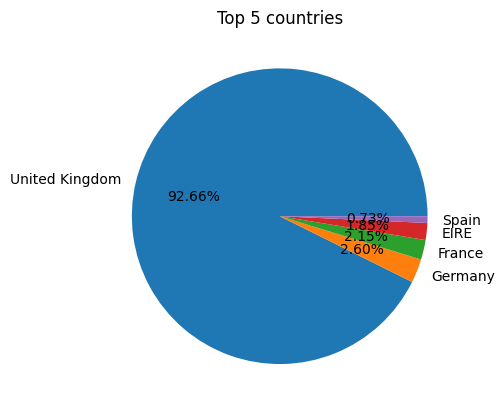

In [93]:
plt.pie(country_val[:5],labels=country_names[:5],autopct='%1.2f%%')
plt.title('Top 5 countries')
plt.show()

These are the top 5 purchaser countries

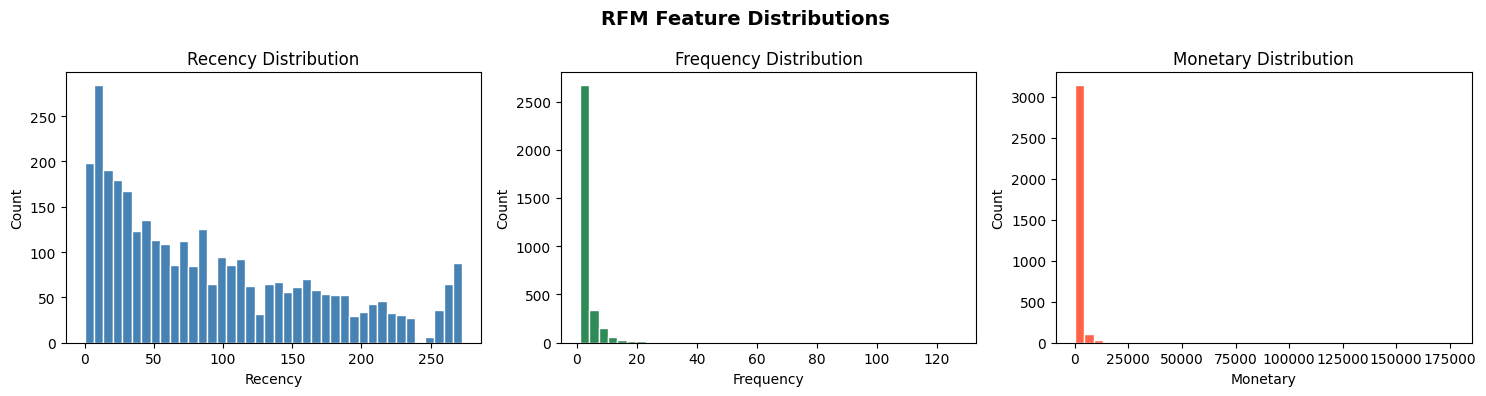

In [94]:
# RFM Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                           ['Recency', 'frequency', 'Monetary'],
                           ['steelblue', 'seagreen', 'tomato']):
    ax.hist(final_df[col], bins=40, color=color, edgecolor='white')
    ax.set_title(f'{col.capitalize()} Distribution')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')

plt.suptitle('RFM Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150)
plt.show()

### Segmenting the users:
#### First we are following the Custom Business - Defined Bins approach
Based on the statistics of RFM columns, the bins are defines here.

In [98]:
final_df.isna().sum()

CustomerID         0
last_purchase      0
first_purchase     0
Recency            0
frequency          0
Monetary           0
Avg_Order_value    0
unique_products    0
total_items        0
dtype: int64

In [101]:

# Recency score — lower recency = better (bought recently)
final_df['R_score'] = pd.cut(
    final_df['Recency'],
    bins  = [-1, 30, 75, 95, final_df['Recency'].max() + 1],
    labels= [4, 3, 2, 1],   # 4 = most recent, 1 = most dormant
    right = True
).astype(int)

# Frequency score — higher = better
final_df['F_score'] = pd.cut(
    final_df['frequency'],
    bins  = [0, 3, 4, 6, final_df['frequency'].max() + 1],
    labels= [1, 2, 3, 4],
    right = True
).astype(int)

# Monetary score — higher = better
final_df['M_score'] = pd.cut(
    final_df['Monetary'],
    bins  = [2, 300, 600, 1600, final_df['Monetary'].max() + 1],
    labels= [1, 2, 3, 4],
    right = True
).astype(int)

# Combined RFM score string for reference
final_df['RFM_Score'] = (final_df['R_score'].astype(str) +
                    final_df['F_score'].astype(str) +
                    final_df['M_score'].astype(str))

print('Score Distribution:')
print('R_score:', final_df['R_score'].value_counts().sort_index().to_dict())
print('F_score:', final_df['F_score'].value_counts().sort_index().to_dict())
print('M_score:', final_df['M_score'].value_counts().sort_index().to_dict())

Score Distribution:
R_score: {1: 1345, 2: 275, 3: 762, 4: 935}
F_score: {1: 2422, 2: 247, 3: 262, 4: 386}
M_score: {1: 953, 2: 783, 3: 894, 4: 687}


In [103]:
# Assign Business Segments based on RFM scores
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Regular and Premier'        # Recent, frequent, high spenders
    elif r >= 3 and (f >= 2 or m >= 2):
        return 'Loyal Customers'  # Recent + decent engagement
    elif r == 2 or (r >= 2 and f <= 2):
        return 'At Risk'          # Engagement dropping
    else:
        return 'Lost Customers'   # Long gone, low engagement

final_df['Segment_Custom'] = final_df.apply(assign_segment, axis=1)

print('Segment Distribution (Custom Bins):')
print(final_df['Segment_Custom'].value_counts().sort_index())

Segment Distribution (Custom Bins):
Segment_Custom
At Risk                 525
Lost Customers         1345
Loyal Customers         880
Regular and Premier     567
Name: count, dtype: int64


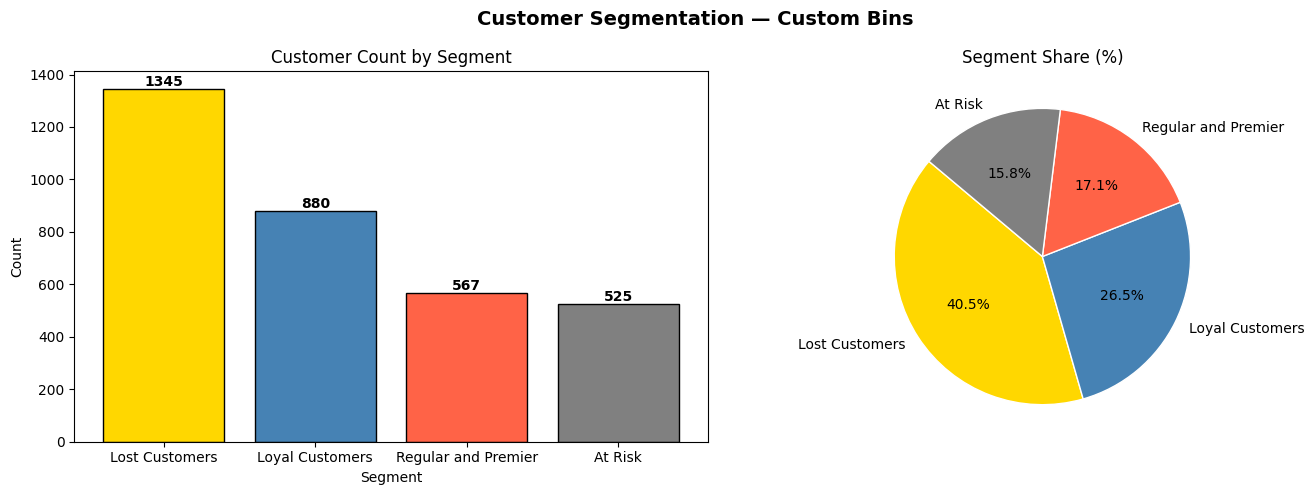

In [104]:
# Visualize custom segments
seg_counts = final_df['Segment_Custom'].value_counts()
colors = ['gold', 'steelblue', 'tomato', 'gray']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(seg_counts.index, seg_counts.values,
            color=colors, edgecolor='black')
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(seg_counts.values, labels=seg_counts.index,
            colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Segment Share (%)')

plt.suptitle('Customer Segmentation — Custom Bins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segments_custom.png', dpi=150)
plt.show()

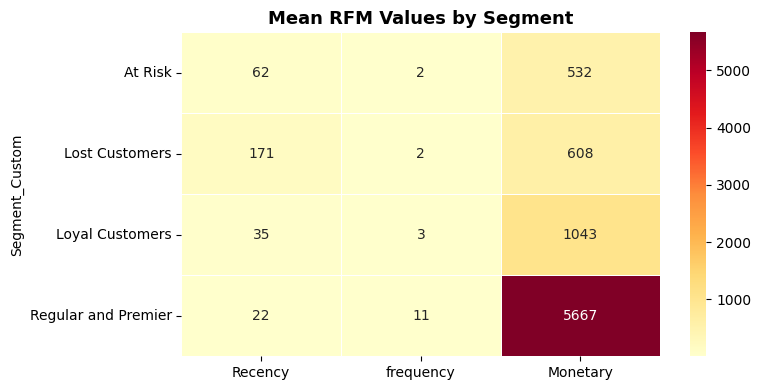

In [106]:
# RFM Heatmap by Segment
seg_heat = final_df.groupby('Segment_Custom')[['Recency', 'frequency', 'Monetary']].mean()

plt.figure(figsize=(8, 4))
sns.heatmap(seg_heat, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title('Mean RFM Values by Segment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### We are using GMM Clustering technique to verify/validate the above Custom bin segments

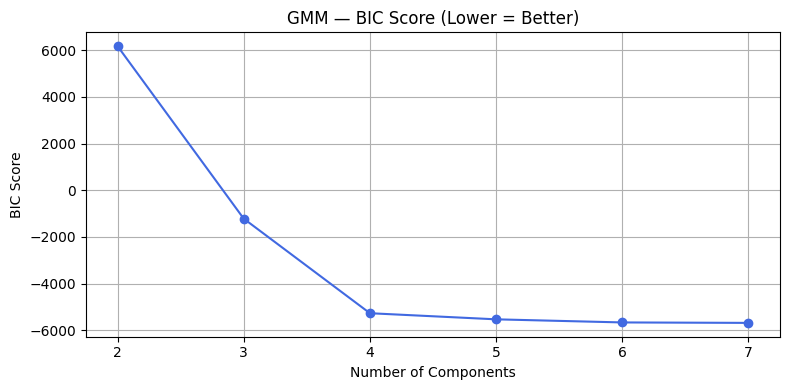

Optimal number of components: 7


In [107]:
# GMM handles unequal cluster sizes and shapes better than K-Means
# It also gives a probability score per customer per cluster

# Step 1: Power transform to fix RFM skewness
from sklearn.preprocessing import PowerTransformer
from sklearn.mixture import GaussianMixture

pt = PowerTransformer(method='yeo-johnson')
final_df_transformed = pt.fit_transform(final_df[['Recency', 'frequency', 'Monetary']])

# Step 2: Find optimal number of components using BIC score
# Lower BIC = better model
bic_scores = []
n_range    = range(2, 8)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    gmm.fit(final_df_transformed)
    bic_scores.append(gmm.bic(final_df_transformed))

plt.figure(figsize=(8, 4))
plt.plot(n_range, bic_scores, marker='o', color='royalblue')
plt.title('GMM — BIC Score (Lower = Better)')
plt.xlabel('Number of Components')
plt.ylabel('BIC Score')
plt.xticks(n_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('gmm_bic.png', dpi=150)
plt.show()

optimal_n = n_range[np.argmin(bic_scores)]
print(f'Optimal number of components: {optimal_n}')

In [115]:
# Step 3: Fitting final GMM with optimal components
gmm_final = GaussianMixture(n_components=4, random_state=42, n_init=10)
final_df['GMM_Cluster'] = gmm_final.fit_predict(final_df_transformed)

# Confidence score per customer (max probability across clusters)
probs = gmm_final.predict_proba(final_df_transformed)
final_df['GMM_Confidence'] = probs.max(axis=1)

# Step 4: Interpret GMM clusters by their RFM profiles
gmm_summary = final_df.groupby('GMM_Cluster')[['Recency', 'frequency', 'Monetary']].mean().round(1)
print('GMM Cluster Mean RFM:')
print(gmm_summary)


GMM Cluster Mean RFM:
             Recency  frequency  Monetary
GMM_Cluster                              
0               88.0        2.0     705.8
1               37.4        8.4    4135.2
2               64.1        3.0    1308.0
3              137.7        1.0     399.9


In [116]:
# Step 5: Map GMM clusters to labels
# Review gmm_summary and assign labels accordingly:
# Low recency + High freq + High monetary = Premier
# Adjust mapping after reviewing your output
gmm_labels = {
    0: 'At Risk',    # high recency, low frequency & monetary
    1: 'Regular and Premier',        # lowest recency, highest frequency & monetary
    2: 'Loyal Customers',  # medium recency, decent frequency & monetary
    3: 'Lost Customers'          # highest recency, lowest frequency & monetary
}

final_df['Segment_GMM'] = final_df['GMM_Cluster'].map(gmm_labels)

print('\nGMM Segment Distribution:')
print(final_df['Segment_GMM'].value_counts())



GMM Segment Distribution:
Segment_GMM
Lost Customers         1376
Regular and Premier     895
At Risk                 651
Loyal Customers         395
Name: count, dtype: int64


In [119]:
final_df.head()

,CustomerID,last_purchase,first_purchase,Recency,frequency,Monetary,Avg_Order_value,unique_products,total_items,R_score,F_score,M_score,RFM_Score,Segment_Custom,GMM_Cluster,GMM_Confidence,Segment_GMM
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,225,1,77183.60,77183.600000,1,74215,1,1,4,114,Lost Customers,3,1.000000,Lost Customers
1,12347,2011-08-02 08:48:00,2010-12-07 14:57:00,29,5,2790.86,558.172000,82,1590,4,3,4,434,Regular and Premier,1,1.000000,Regular and Premier
2,12348,2011-04-05 10:47:00,2010-12-16 19:09:00,148,3,1487.24,495.746667,22,2124,1,1,3,113,Lost Customers,2,0.999706,Loyal Customers
3,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,210,1,334.40,334.400000,17,197,1,1,2,112,Lost Customers,3,1.000000,Lost Customers
4,12352,2011-03-22 16:08:00,2011-02-16 12:33:00,162,5,1561.81,312.362000,26,254,1,3,3,133,Lost Customers,1,1.000000,Regular and Premier


In [120]:
# Finalizing the Segment column
# Using Custom Bins as primary — GMM validates it
final_df['Segment'] = final_df['Segment_Custom']
print('Final segment column set to Custom Bins.')
print(final_df['Segment'].value_counts())

Final segment column set to Custom Bins.
Segment
Lost Customers         1345
Loyal Customers         880
Regular and Premier     567
At Risk                 525
Name: count, dtype: int64


### Churn Label
Here we are deriving the churn label from the prediction window

In [121]:
# Customers who purchased in prediction window (Sep-Dec 2011) = Active (0)
# Customers who did NOT return in prediction window = Churned (1)
active_in_future = predict_df['CustomerID'].unique()

final_df['churn'] = final_df['CustomerID'].apply(
    lambda x: 0 if x in active_in_future else 1
)

churn_counts = final_df['churn'].value_counts()
print('Churn Distribution:')
print(f'  Active   (churn=0): {churn_counts[0]}')
print(f'  Churned  (churn=1): {churn_counts[1]}')
print(f'  Churn Rate        : {final_df["churn"].mean()*100:.1f}%')

# Churn rate by segment
print('\nChurn Rate by Segment:')
churn_by_seg = final_df.groupby('Segment')['churn'].mean().sort_values(ascending=False)
print((churn_by_seg * 100).round(1).astype(str) + '%')

Churn Distribution:
  Active   (churn=0): 1952
  Churned  (churn=1): 1365
  Churn Rate        : 41.2%

Churn Rate by Segment:
Segment
Lost Customers         57.7%
At Risk                46.9%
Loyal Customers        35.0%
Regular and Premier     6.2%
Name: churn, dtype: object


### Build Churn Prediction Model

In [124]:
# Customer age = how long they've been a customer (in days)
final_df['customer_age_days'] = (obs_date - final_df['first_purchase']).dt.days

In [125]:
# Features include recency (safe because of time-based split)
model_features = [
    'Recency', 'frequency', 'Monetary',
    'total_items', 'unique_products',
    'Avg_Order_value', 'customer_age_days'
]

X = final_df[model_features]
y = final_df['churn']

print('Features:', model_features)
print('X shape :', X.shape)
print('y shape :', y.shape)
print('\nChurn balance:')
print(y.value_counts())
print(f'Ratio (Active:Churned): {y.value_counts()[0]}:{y.value_counts()[1]}')

Features: ['Recency', 'frequency', 'Monetary', 'total_items', 'unique_products', 'Avg_Order_value', 'customer_age_days']
X shape : (3317, 7)
y shape : (3317,)

Churn balance:
churn
0    1952
1    1365
Name: count, dtype: int64
Ratio (Active:Churned): 1952:1365


In [127]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

#### Feature Scaling and Train-Test-Split

In [128]:
# Train/Test Split — stratify preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'\nChurn ratio in Train: {y_train.mean()*100:.1f}%')
print(f'Churn ratio in Test : {y_test.mean()*100:.1f}%')

# Scale for Logistic Regression only (tree models don't need scaling)
scaler    = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train size : (2653, 7)
Test size  : (664, 7)

Churn ratio in Train: 41.2%
Churn ratio in Test : 41.1%


In [136]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [137]:
def evaluate_model(true, predicted, test_proba):
    acc = accuracy_score(true, predicted)
    cm = confusion_matrix(true, predicted)
    precision = precision_score(true, predicted, average='weighted')
    recall = recall_score(true, predicted, average='weighted')
    f1 = f1_score(true, predicted, average='weighted')
    roc_auc =  roc_auc_score(true, test_proba)
    report = classification_report(true, predicted)
    return acc,cm, precision, recall, f1, report, roc_auc

#### Training various models

In [139]:

models = {
    
    "AdaBoost Classifier": AdaBoostClassifier(learning_rate=0.8, n_estimators=100,algorithm='SAMME.R', random_state=42),
    
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}
model_list = []
acc_list =[]
f1_list=[]
prec_list = []
recall_list = []
roc_auc_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_sc, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_sc)
    y_test_pred = model.predict(X_test_sc)
    y_test_proba = model.predict_proba(X_test_sc)[:, 1]
    y_train_proba = model.predict_proba(X_train_sc)[:, 1]
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Training Set Evaluation:")
    train_acc, train_cm, train_precision, train_recall, train_f1, train_report, train_roc_auc = evaluate_model(y_train, y_train_pred, y_train_proba)
    print("Accuracy Score: ", train_acc)
    print("Precision Score: ", train_precision)
    print("Recall Score: ", train_recall)
    print("F1 Score: ", train_f1)
    print("\nConfusion Matrix: ", train_cm)
    print("\nClassification report: ",train_report)

    print('----------------------------------')
    
    print("Test Set Evaluation:")
    test_acc, test_cm, test_precision, test_recall, test_f1, test_report, test_roc_auc = evaluate_model(y_test, y_test_pred, y_test_proba)
    print("Accuracy Score: ", test_acc)
    print("Precision Score: ", test_precision)
    print("Recall Score: ", test_recall)
    print("F1 Score: ", test_f1)
    print("\nConfusion Matrix: ", test_cm)
    print("\nClassification report: ",test_report)
    
    acc_list.append(test_acc)
    f1_list.append(test_f1)
    prec_list.append(test_precision)
    recall_list.append(test_recall)
    roc_auc_list.append(test_roc_auc)
    
    
    print("="*40, "\n")



AdaBoost Classifier
Training Set Evaluation:
Accuracy Score:  0.7097625329815304
Precision Score:  0.711636834115343
Recall Score:  0.7097625329815304
F1 Score:  0.7105217304724448

Confusion Matrix:  [[1155  406]
 [ 364  728]]

Classification report:                precision    recall  f1-score   support

           0       0.76      0.74      0.75      1561
           1       0.64      0.67      0.65      1092

    accuracy                           0.71      2653
   macro avg       0.70      0.70      0.70      2653
weighted avg       0.71      0.71      0.71      2653

----------------------------------
Test Set Evaluation:
Accuracy Score:  0.6671686746987951
Precision Score:  0.672126852002605
Recall Score:  0.6671686746987951
F1 Score:  0.6688525952347495

Confusion Matrix:  [[269 122]
 [ 99 174]]

Classification report:                precision    recall  f1-score   support

           0       0.73      0.69      0.71       391
           1       0.59      0.64      0.61       2

In [140]:
#scale ratio for XGB
scale_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    
    "Random Forest Classifier": RandomForestClassifier(n_estimators = 100, max_depth = 6, min_samples_split = 20,
                                                       min_samples_leaf = 10, max_features = 'sqrt', random_state = 42, n_jobs = -1),
    
    "XGBClassifier": XGBClassifier(n_estimators = 200,learning_rate = 0.05,max_depth = 3,subsample = 0.8,colsample_bytree = 0.8,
                                   reg_alpha = 0.1,reg_lambda = 1.0,scale_pos_weight = scale_ratio,eval_metric = 'logloss',
                                   random_state = 42, n_jobs = -1), 
    
    "GradientBoosting Classifier": GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 3,
                                                              subsample = 0.8,random_state  = 42),
}
model_list = []
acc_list =[]
f1_list=[]
prec_list = []
recall_list = []
roc_auc_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_train_proba = model.predict_proba(X_train_sc)[:, 1]
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Training Set Evaluation:")
    train_acc, train_cm, train_precision, train_recall, train_f1, train_report, train_roc_auc = evaluate_model(y_train, y_train_pred, y_train_proba)
    print("Accuracy Score: ", train_acc)
    print("Precision Score: ", train_precision)
    print("Recall Score: ", train_recall)
    print("F1 Score: ", train_f1)
    print("\nConfusion Matrix: ", train_cm)
    print("\nClassification report: ",train_report)

    print('----------------------------------')
    
    print("Test Set Evaluation:")
    test_acc, test_cm, test_precision, test_recall, test_f1, test_report, test_roc_auc = evaluate_model(y_test, y_test_pred, y_test_proba)
    print("Accuracy Score: ", test_acc)
    print("Precision Score: ", test_precision)
    print("Recall Score: ", test_recall)
    print("F1 Score: ", test_f1)
    print("\nConfusion Matrix: ", test_cm)
    print("\nClassification report: ",test_report)
    
    acc_list.append(test_acc)
    f1_list.append(test_f1)
    prec_list.append(test_precision)
    recall_list.append(test_recall)
    roc_auc_list.append(test_roc_auc)
    
    
    print("="*40, "\n")



Random Forest Classifier
Training Set Evaluation:
Accuracy Score:  0.7387862796833773
Precision Score:  0.7394347293269383
Recall Score:  0.7387862796833773
F1 Score:  0.7390799781599025

Confusion Matrix:  [[1206  355]
 [ 338  754]]

Classification report:                precision    recall  f1-score   support

           0       0.78      0.77      0.78      1561
           1       0.68      0.69      0.69      1092

    accuracy                           0.74      2653
   macro avg       0.73      0.73      0.73      2653
weighted avg       0.74      0.74      0.74      2653

----------------------------------
Test Set Evaluation:
Accuracy Score:  0.6626506024096386
Precision Score:  0.6689182252747295
Recall Score:  0.6626506024096386
F1 Score:  0.6646148545790849

Confusion Matrix:  [[265 126]
 [ 98 175]]

Classification report:                precision    recall  f1-score   support

           0       0.73      0.68      0.70       391
           1       0.58      0.64      0.61 

### Hyper Parameter Tuning

In [142]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, GridSearchCV

In [146]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [147]:
#scale ratio for XGB
scale_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

models = {
    
    "Random Forest Classifier": RandomForestClassifier(n_estimators = 100, max_depth = 6, min_samples_split = 20,
                                                       min_samples_leaf = 10, max_features = 'sqrt', random_state = 42, n_jobs = -1),
    
    "XGBClassifier": XGBClassifier(n_estimators = 200,learning_rate = 0.05,max_depth = 3,subsample = 0.8,colsample_bytree = 0.8,
                                   reg_alpha = 0.1,reg_lambda = 1.0,scale_pos_weight = scale_ratio,eval_metric = 'logloss',
                                   random_state = 42, n_jobs = -1), 
    
    "GradientBoosting Classifier": GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.05, max_depth = 3,
                                                              subsample = 0.8,random_state  = 42),
}

params={
                "Random Forest Classifier":{
                    'n_estimators'    : [100, 200, 300],
                    'max_depth'       : [4, 5, 6, 7, None],
                    'min_samples_split': [10, 20, 30, 50],
                    'min_samples_leaf' : [5, 10, 15, 20],
                    'max_features'    : ['sqrt', 'log2'],
                    'class_weight'    : ['balanced', None]  # handles mild imbalance
                },
                "XGBClassifier":{
                    'n_estimators'    : [100, 200, 300, 500],
                    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
                    'max_depth'       : [2, 3, 4, 5],
                    'subsample'       : [0.6, 0.7, 0.8, 1.0],
                    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
                    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
                    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
                    'scale_pos_weight': [1, scale_ratio]
                },
                "GradientBoosting Classifier": {
                    'n_estimators'   : [100, 200, 300],
                    'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
                    'max_depth'      : [2, 3, 4, 5],
                    'subsample'      : [0.6, 0.7, 0.8, 1.0],
                    'min_samples_leaf': [5, 10, 20, 30],
                    'max_features'   : ['sqrt', 'log2', None]
                }
                
            }

model_list = []
acc_list =[]
f1_list=[]
prec_list = []
recall_list = []
roc_auc_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    para=params[list(models.keys())[i]]
    gs = RandomizedSearchCV(estimator= model, param_distributions= para,n_iter= 20,cv = cv,scoring= 'roc_auc',
                            n_jobs= -1, random_state = 42,verbose= 1)
    gs.fit(X_train,y_train)
    
    model.set_params(**gs.best_params_)
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_train_proba = model.predict_proba(X_train_sc)[:, 1]
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print("Training Set Evaluation:")
    train_acc, train_cm, train_precision, train_recall, train_f1, train_report, train_roc_auc = evaluate_model(y_train, y_train_pred, y_train_proba)
    print("Accuracy Score: ", train_acc)
    print("Precision Score: ", train_precision)
    print("Recall Score: ", train_recall)
    print("F1 Score: ", train_f1)
    print("\nConfusion Matrix: ", train_cm)
    print("\nClassification report: ",train_report)

    print('----------------------------------')
    
    print("Test Set Evaluation:")
    test_acc, test_cm, test_precision, test_recall, test_f1, test_report, test_roc_auc = evaluate_model(y_test, y_test_pred, y_test_proba)
    print("Accuracy Score: ", test_acc)
    print("Precision Score: ", test_precision)
    print("Recall Score: ", test_recall)
    print("F1 Score: ", test_f1)
    print("ROC Score: ", test_roc_auc)
    print("\nConfusion Matrix: ", test_cm)
    print("\nClassification report: ",test_report)
    
    
    acc_list.append(test_acc)
    f1_list.append(test_f1)
    prec_list.append(test_precision)
    recall_list.append(test_recall)
    roc_auc_list.append(test_roc_auc)
    
    
    print("="*40, "\n")



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest Classifier
Training Set Evaluation:
Accuracy Score:  0.7101394647568791
Precision Score:  0.7102601018819407
Recall Score:  0.7101394647568791
F1 Score:  0.7101988710020761

Confusion Matrix:  [[1175  386]
 [ 383  709]]

Classification report:                precision    recall  f1-score   support

           0       0.75      0.75      0.75      1561
           1       0.65      0.65      0.65      1092

    accuracy                           0.71      2653
   macro avg       0.70      0.70      0.70      2653
weighted avg       0.71      0.71      0.71      2653

----------------------------------
Test Set Evaluation:
Accuracy Score:  0.6641566265060241
Precision Score:  0.6686473694003815
Recall Score:  0.6641566265060241
F1 Score:  0.6657421040564653

Confusion Matrix:  [[269 122]
 [101 172]]

Classification report:                precision    recall  f1-score   support

           0       0.73      0.69   

#### From the baove results, XGB and GradientBoost performed better after hyperparameter tuning. Here's the key takeaways:
- In the case of XGB, it reduced false positives
- Whereas GradientBoosting classifier reduced false negatives

False Negative - The customers are actually churned, but predicted as not churned
False Positive - The customer are not churned, but predicted as churned

Since our main agenda is to predict the Customers who are likely to churn, we need to reduce the False negative. 

**We are now finalizing our model as GradientBoosting Classifier.**

In [165]:
params={
                    'n_estimators'   : [100, 200, 300],
                    'learning_rate'  : [0.01, 0.05, 0.1, 0.2],
                    'max_depth'      : [2, 3, 4, 5],
                    'subsample'      : [0.6, 0.7, 0.8, 1.0],
                    'min_samples_leaf': [5, 10, 20, 30],
                    'max_features'   : ['sqrt', 'log2', None]
                
            }

gb = GradientBoostingClassifier()

rs = RandomizedSearchCV(estimator= gb, param_distributions= params,n_iter= 20,cv = cv,scoring= 'roc_auc',
                            n_jobs= -1, random_state = 42,verbose= 1)
rs.fit(X_train,y_train)
    
gb.set_params(**gs.best_params_)
gb.fit(X_train, y_train)



# Make predictions
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)
y_test_proba = gb.predict_proba(X_test)[:, 1]
y_train_proba = gb.predict_proba(X_train_sc)[:, 1]
    
    
print("Training Set Evaluation:")
train_acc, train_cm, train_precision, train_recall, train_f1, train_report, train_roc_auc = evaluate_model(y_train, y_train_pred, y_train_proba)
print("Accuracy Score: ", train_acc)
print("Precision Score: ", train_precision)
print("Recall Score: ", train_recall)
print("F1 Score: ", train_f1)
print("\nConfusion Matrix: ", train_cm)
print("\nClassification report: ",train_report)

print('----------------------------------')
    
print("Test Set Evaluation:")
test_acc, test_cm, test_precision, test_recall, test_f1, test_report, test_roc_auc = evaluate_model(y_test, y_test_pred, y_test_proba)
print("Accuracy Score: ", test_acc)
print("Precision Score: ", test_precision)
print("Recall Score: ", test_recall)
print("F1 Score: ", test_f1)
print("ROC Score: ", test_roc_auc)
print("\nConfusion Matrix: ", test_cm)
print("\nClassification report: ",test_report)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
Training Set Evaluation:
Accuracy Score:  0.7044854881266491
Precision Score:  0.7044854881266491
Recall Score:  0.7044854881266491
F1 Score:  0.7044854881266491

Confusion Matrix:  [[1169  392]
 [ 392  700]]

Classification report:                precision    recall  f1-score   support

           0       0.75      0.75      0.75      1561
           1       0.64      0.64      0.64      1092

    accuracy                           0.70      2653
   macro avg       0.69      0.69      0.69      2653
weighted avg       0.70      0.70      0.70      2653

----------------------------------
Test Set Evaluation:
Accuracy Score:  0.6762048192771084
Precision Score:  0.6801319839676868
Recall Score:  0.6762048192771084
F1 Score:  0.6776176371825348
ROC Score:  0.7455992430416982

Confusion Matrix:  [[274 117]
 [ 98 175]]

Classification report:                precision    recall  f1-score   support

           0       0.74      0

In [168]:
final_model      = gb
final_model_name = 'Gradient Boosting'

# Save updated model
import joblib
joblib.dump(final_model, 'final_churn_model.pkl')
print('Final model: Gradient Boosting')

Final model: Gradient Boosting


### Estimating the Customer Lifetime Value (CLV)

In [159]:
# CLV Formula: Avg Order Value × Purchase Frequency × Customer Lifespan (years)
final_df['customer_lifespan_years'] = (final_df['customer_age_days'] / 365)

final_df['CLV'] = (
    final_df['Avg_Order_value'] *
    final_df['frequency'] *
    final_df['customer_lifespan_years']
)

print('CLV Summary:')
print(final_df['CLV'].describe().round(2))

print('\nAverage CLV by Segment:')
clv_segment = final_df.groupby('Segment')['CLV'].mean().sort_values(ascending=False).round(2)
print(clv_segment)

CLV Summary:
count      3317.00
mean        963.56
std        4216.96
min           0.00
25%          87.08
50%         243.88
75%         713.28
max      122724.41
Name: CLV, dtype: float64

Average CLV by Segment:
Segment
Regular and Premier    3895.78
Loyal Customers         455.91
Lost Customers          346.68
At Risk                 228.11
Name: CLV, dtype: float64


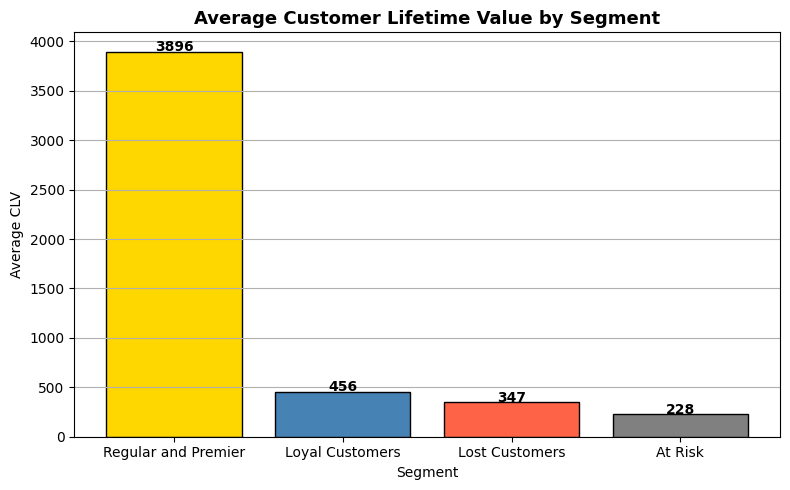

In [162]:
# CLV by Segment — Bar Chart
clv_df = clv_segment.reset_index()
clv_df.columns = ['Segment', 'Avg_CLV']
clv_df = clv_df.sort_values('Avg_CLV', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(clv_df['Segment'], clv_df['Avg_CLV'],
               color=['gold', 'steelblue', 'tomato', 'gray'],
               edgecolor='black')
for bar, val in zip(bars, clv_df['Avg_CLV']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}', ha='center', fontweight='bold')
plt.title('Average Customer Lifetime Value by Segment',
          fontsize=13, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Average CLV')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [166]:
print("\n" + "="*60)
print("FINAL BUSINESS INSIGHTS SUMMARY")
print("="*60)
 
summary = final_df.groupby('Segment').agg(
    customer_count = ('CustomerID', 'count'),
    avg_recency    = ('Recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('Monetary', 'mean'),
    avg_clv        = ('CLV', 'mean'),
    churn_rate     = ('churn', 'mean')
).round(2)
 
summary['churn_rate'] = (summary['churn_rate'] * 100).round(1).astype(str) + '%'
print(summary.to_string())
 
# Add churn probability from GradientBoosting Classifier to final_df table
final_df['churn_probability'] = gb.predict_proba(
    final_df[model_features])[:, 1]
 
# High-Risk & High-Value customers
high_risk   = final_df[(final_df['churn_probability'] > 0.7) & (final_df['CLV'] > final_df['CLV'].median())]
high_value  = final_df[(final_df['CLV'] > final_df['CLV'].quantile(0.75)) & (final_df['churn'] == 0)]
 
print(f"\n🔴 High-Risk Customers (High CLV + High Churn Probability): {len(high_risk)}")
print(f"🟢 High-Value Active Customers (Top 25% CLV, Not Churned):  {len(high_value)}")
 
# Export final customer table
final_df.to_csv('customer_segments_final.csv', index=False)



FINAL BUSINESS INSIGHTS SUMMARY
                     customer_count  avg_recency  avg_frequency  avg_monetary  avg_clv churn_rate
Segment                                                                                          
At Risk                         525        61.87           1.86        531.73   228.11      47.0%
Lost Customers                 1345       171.19           1.59        607.64   346.68      58.0%
Loyal Customers                 880        34.62           2.56       1042.72   455.91      35.0%
Regular and Premier             567        21.73          10.67       5667.46  3895.78       6.0%

🔴 High-Risk Customers (High CLV + High Churn Probability): 4
🟢 High-Value Active Customers (Top 25% CLV, Not Churned):  707


### Conclusion:
- We have performed the Data Cleaning
- We have split the data based on a time window for defining the churn label
- Feature Engineering - used Recency, Frequency, Monetary (RFM) method and defined new features
- Segmented users based on behaviour (RFM), engagement pattern model - Quantile scoring technique
- Created the Churn column in training dataset based on prediction dataset (if customerID is in prediction dataset then active otherwise churn)
- Trained different models and finalized the best performed model
- Performed Hyper parameter tuning and cross validation
- Estimated the Customer life time value and business insights